# Introduction to Language and Speech Technology - ReMA (RU)
*Seminar 12*

Last update: 2024/12/09

Aditya Kamlesh Parikh - @aditya.parikh@ru.nl

In this tutorial, we will explore Text-to-Speech (TTS), focusing on several pre-trained models. Compared to tasks like Automatic Speech Recognition (ASR) and audio classification, significantly fewer pre-trained model checkpoints are available for TTS. Among the most popular and widely used TTS pre-trained models are Speech-T5, Bark, and Massive Multilingual Speech (MMS).

As discussed in the ASR tutorial, TTS models can also be pre-trained and fine-tuned for specific tasks. However, there are key differences between ASR and TTS models, which we will highlight in this tutorial. If you have already understood the fine-tuning process for ASR pre-trained models, grasping TTS fine-tuning will be straightforward, enabling you to perform it yourself.

We will start by reviewing some of the pre-trained models available for TTS. Additionally, we will discuss crucial aspects of speech synthesis, such as vocoders—which generate audio from log mel-spectrograms—and i-vectors and x-vectors, which play important roles in tasks like speaker diarization and speaker identification.

# SpeechT5

[SpeechT5](https://arxiv.org/abs/2110.07205) is a model published by Junyi Ao et al. from Microsoft that is capable of handling a range of speech tasks. This model can be tailored to text-to-speech, speech-to-text tasks (automatic speech recognition or speaker identification), as well as speech-to-speech (e.g. speech enhancement or converting between different voices).



First, let’s load the fine-tuned TTS SpeechT5 model from the 🤗 Hub, along with the processor object used for tokenization and feature extraction:


In [ ]:
from transformers import SpeechT5Processor, SpeechT5ForTextToSpeech

processor = SpeechT5Processor.from_pretrained("microsoft/speecht5_tts")
model = SpeechT5ForTextToSpeech.from_pretrained("microsoft/speecht5_tts")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

preprocessor_config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/232 [00:00<?, ?B/s]

spm_char.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/40.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/585M [00:00<?, ?B/s]

Next tokenization of input text

In [ ]:
inputs = processor(text="hello all, welcome to speech synthesis tutorial", return_tensors="pt")

In [ ]:
inputs.input_ids
# Tokenizer based on sentence piece tokenizer (In speechT5 processor two activities are happening. 1. Feature Extraction 2. Tokenization)

tensor([[ 4, 11,  5, 15, 15,  8,  4,  7, 15, 15, 23,  4, 20,  5, 15, 17,  8, 18,
          5,  4,  6,  8,  4, 12, 24,  5,  5, 17, 11,  4, 12, 22,  9,  6, 11,  5,
         12, 10, 12,  4,  6, 16,  6,  8, 13, 10,  7, 15,  2]])

With SpeechT5 model, you can create speech for multiple speakers based on speaker embeddings. This is where i-vector and x-vectors come to use.

Speaker embeddings are a method of compactly representing a speaker's identity as a fixed-size vector. These embeddings encode essential characteristics of a speaker's voice, such as accent, intonation, and other unique features, making it possible to distinguish one speaker from another. Speaker embeddings are widely used in tasks like:

* Speaker verification: Confirming a speaker's identity.
* Speaker diarization: Segmenting audio into parts spoken by different speakers.
* Speaker identification: Recognizing who is speaking.



We will take a embedding dataset from CMU embeddings corpus.

The CMU ARCTIC dataset divides the utterances among the following speakers:

1. bdl (US male)
2. slt (US female)
3. jmk (Canadian male)
4. awb (Scottish male)
5. rms (US male)
6. clb (US female)
7. ksp (Indian male)

In [ ]:
%%capture
!pip install datasets

In [ ]:
from datasets import load_dataset
import torch

embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")

In [ ]:
embeddings_dataset

Dataset({
    features: ['filename', 'xvector'],
    num_rows: 7931
})

In [ ]:
print(len(embeddings_dataset[7500]['xvector']))
print(embeddings_dataset[7500]['filename'])

512
cmu_us_slt_arctic-wav-arctic_b0109


In [ ]:
# We will take embeddings of "slt (US female)"
speaker_embeddings = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speaker_embeddings.shape

torch.Size([1, 512])

Finally based on the speaker embeddings we generate the log mel-spectrogram as an output.

In [ ]:
spectrogram = model.generate_speech(inputs["input_ids"], speaker_embeddings)

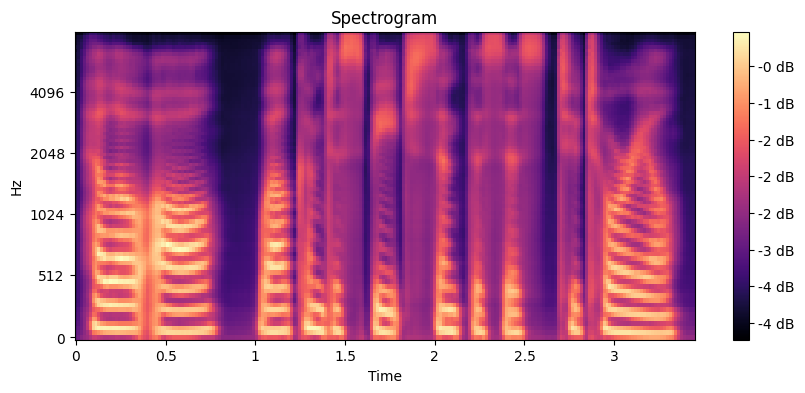

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

# Convert the tensor to a numpy array
spectrogram_np = spectrogram.cpu().numpy()

# Display the spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(spectrogram_np.T, sr=16000, hop_length=256, x_axis="time", y_axis="mel")  # Adjust parameters as needed
plt.colorbar(format="%+2.f dB")
plt.title("Spectrogram")
plt.show()

In [ ]:
spectrogram.shape

torch.Size([216, 80])

The first dimension is the sequence length, and it may vary between runs as the speech decoder pre-net always applies dropout to the input sequence. This adds a bit of random variability to the generated speech.


But now, you also need to convert this spectrogram to the syntheysed voice. For that, we need another one important component namely **Vocoder**. A vocoder is used for the spectrogram to waveform conversion. You can use any opensource vocoders which can work on 80 bin mel spectrograms.


With 🤗, you can use HiFi-GAN vocoder. It is a state-of-the-art generative adversarial network (GAN) designed for high-fidelity speech synthesis. It is capable of generating high-quality and realistic audio waveforms from spectrogram inputs. Learning of HiFi-GAN is also very interesting but out of scope of this tutorial. https://arxiv.org/pdf/2010.05646  

In [ ]:
# Load the vocoder
from transformers import SpeechT5HifiGan
vocoder = SpeechT5HifiGan.from_pretrained("microsoft/speecht5_hifigan")

Now we will generate the speech from our spectrogram.

In [ ]:
speech = model.generate_speech(inputs["input_ids"], speaker_embeddings, vocoder=vocoder)

In [ ]:
from IPython.display import Audio
Audio(speech, rate=16000)

This was the tutorial.

**Task 1**: Now you know about one pretrained model SpeechT5, please do some experiment with others like Bark or MMS.  Bark generates raw speech waveforms directly, eliminating the need for a separate vocoder during inference – it’s already integrated. But Bark has it's own [speaker embedding library](https://suno-ai.notion.site/8b8e8749ed514b0cbf3f699013548683?v=bc67cff786b04b50b3ceb756fd05f68c) from which you can choose the speaker for different languages. But not just that, it can also generate music, non-verbal communications such as laughing, sighing and crying. You just have to modify the input text with corresponding cues such as [clears throat], [laughter] etc. Try it. https://huggingface.co/suno/bark-small

For generating X-vectors

https://github.com/speechbrain/speechbrain/blob/develop/speechbrain/lobes/models/Xvector.py